In [1]:
!pip install yfinance requests numpy pandas matplotlib scipy

In [2]:
import pandas as pd
import requests
import numpy as np
from datetime import datetime, timedelta
import time
import yfinance as yf

btc = yf.download("BTC-USD", start="2025-10-01", end="2025-10-16", interval="1h")
btc = btc.reset_index()[["Datetime", "Close"]]
btc.rename(columns={"Datetime": "window", "Close": "price"}, inplace=True)
btc["window"] = pd.to_datetime(btc["window"])

API_KEY = "0e30c2fd9f294f21b216b290a6edd700"
def fetch_newsapi_news(query="bitcoin", start_date="2025-10-01", end_date="2025-10-16"):
    base_url = "https://newsapi.org/v2/everything"
    all_articles = []
    start = datetime.strptime(start_date, "%Y-%m-%d")
    end = datetime.strptime(end_date, "%Y-%m-%d")
    delta = timedelta(days=1)
    while start <= end:
        from_str = start.strftime("%Y-%m-%d")
        to_str = (start + delta).strftime("%Y-%m-%d")
        params = {
            "q": query,
            "from": from_str,
            "to": to_str,
            "language": "en",
            "sortBy": "publishedAt",
            "pageSize": 100,
            "apiKey": API_KEY
        }
        try:
            r = requests.get(base_url, params=params, timeout=10)
            data = r.json()
            if "articles" in data and data["articles"]:
                all_articles.extend(data["articles"])
        except Exception as e:
            print(f"Ошибка {e} на дате {from_str}")
        start += delta
        time.sleep(0.5)

    df = pd.DataFrame(all_articles)[["title", "publishedAt"]]
    df["publishedAt"] = pd.to_datetime(df["publishedAt"], errors="coerce")
    df.dropna(subset=["title", "publishedAt"], inplace=True)
    return df

news_df = fetch_newsapi_news("bitcoin", "2025-10-01", "2025-10-15")
print(len(news_df))
print(news_df.head())

C:\Users\peche\AppData\Local\Temp\ipykernel_27308\1824972657.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2025-10-01", end="2025-10-16", interval="1h")
[*********************100%***********************]  1 of 1 completed


1493
                                               title               publishedAt
0  Why BlackRock's Bitcoin ETF proves 'ETFs are n... 2025-10-02 23:40:14+00:00
1  ‘Horse has left the barn:’ ETHZilla bets big o... 2025-10-02 23:33:45+00:00
2  Betting markets like Kalshi see the government... 2025-10-02 23:32:36+00:00
3  Hackers say they have deleted children’s pictu... 2025-10-02 23:22:36+00:00
4  Will a Europe-US BTC reserve race actually hap... 2025-10-02 23:14:39+00:00


In [3]:
news_df.to_csv("news_df.csv", index=False, encoding="utf-8")

In [4]:
from sentence_transformers import SentenceTransformer

news_df["window"] = news_df["publishedAt"].dt.floor("1H")

model = SentenceTransformer('all-MiniLM-L6-v2')
texts = (news_df['title']).tolist()
embeddings = model.encode(texts, batch_size=32, show_progress_bar=True)
news_df['embedding'] = list(embeddings)

emb_df = (
    news_df.groupby("window")["embedding"]
    .apply(lambda x: np.mean(np.vstack(x), axis=0))
    .reset_index()
)
print(emb_df.columns)
print(emb_df.head())

C:\Users\peche\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\peche\AppData\Local\Temp\ipykernel_27308\1516966128.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  news_df["window"] = news_df["publishedAt"].dt.floor("1H")
Batches: 100%|█████████████████████████████████████████████████████████████████████████| 47/47 [00:17<00:00,  2.69it/s]

Index(['window', 'embedding'], dtype='object')
                     window                                          embedding
0 2025-10-02 15:00:00+00:00  [-0.014783943, -0.008214497, -0.016352395, 0.0...
1 2025-10-02 16:00:00+00:00  [-0.005254599, -0.02827082, -0.01893014, 0.037...
2 2025-10-02 17:00:00+00:00  [-0.0306693, -0.011771872, -0.02398631, 0.0239...
3 2025-10-02 18:00:00+00:00  [0.012794882, -0.019390801, -0.009768997, 0.01...
4 2025-10-02 19:00:00+00:00  [-0.020431414, 0.0043695187, -0.019274043, 0.0...


In [5]:
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

btc.columns = [col[0] if isinstance(col, tuple) else col for col in btc.columns]
btc = btc.rename(columns={"Datetime": "window", "Close": "price"})
print(btc.columns)
print(emb_df.columns)

data = pd.merge(emb_df, btc, on="window", how="inner")
print(len(data))
X = np.vstack(data["embedding"])
Y = data[["price"]].values
X = StandardScaler().fit_transform(X)
Y = StandardScaler().fit_transform(Y.reshape(-1, 1)).ravel()

corrs = np.array([pearsonr(X[:, i], Y)[0] for i in range(X.shape[1])])
corr_df = pd.DataFrame({
    "component": np.arange(len(corrs)),
    "pearson_corr": corrs
})
print(corr_df.head())

Index(['window', 'price'], dtype='object')
Index(['window', 'embedding'], dtype='object')
153
   component  pearson_corr
0          0      0.037437
1          1     -0.243407
2          2     -0.197988
3          3      0.039677
4          4     -0.112057


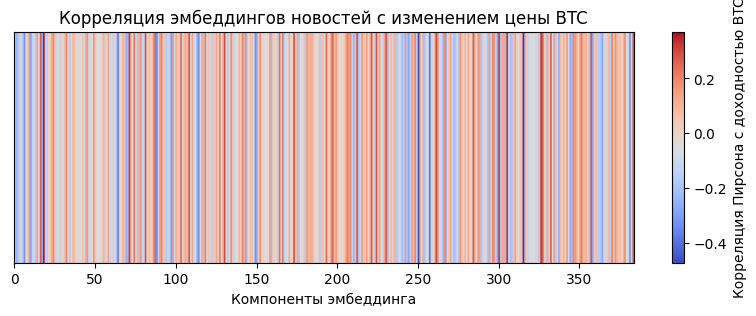

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 3))
plt.imshow(corrs.reshape(1, -1), cmap="coolwarm", aspect="auto")
plt.colorbar(label="Корреляция Пирсона с доходностью BTC")
plt.yticks([])
plt.xlabel("Компоненты эмбеддинга")
plt.title("Корреляция эмбеддингов новостей с изменением цены BTC")
plt.show()